## TASK 1 — ANOVA (Day-of-Week)

In [2]:
# import libraries
import pandas as pd, yfinance as yf

# select assets and benchmark
TICKER = ["NVDA", "AMD", "INTC"]
BENCH  = ["QQQ"] 
TICKER = TICKER + BENCH

# 3 year period
end = pd.Timestamp.today().normalize()
start = end - pd.DateOffset(months=36)

# download adjusted close prices
df = yf.download(TICKER, start=start, end=end, interval="1d", auto_adjust=True)[["Close"]]

# flatten column names if multi-index
# i am not sure why the template appends an extra index on the columns
df.columns = [col if isinstance(col, str) else col[1] for col in df.columns]

# reset index to make Date a column
df = df.reset_index()

# sort values by date
df = df.sort_values("Date")

# forward fill and drop any NAs
df = df.ffill().dropna()

# compute returns
df_returns = df[TICKER].pct_change().rename(columns=lambda x: x+ "_Return")

# align return columns to match df
price_cols = df.columns[1:]
df_returns = df_returns[[col + "_Return" for col in price_cols]]

# concatting two datas
df = pd.concat([df, df_returns], axis=1)

# save files
df.to_csv("prices_clean.csv", index=False)

[*********************100%***********************]  4 of 4 completed


## NVDA

In [14]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

asset = "NVDA"

# load clean prices
df = pd.read_csv("prices_clean.csv", parse_dates=["Date"])
df = df.sort_values("Date").dropna()

# rolling 20‑day stdev of returns for volatility proxy.
df["Vol20"] = df[asset].rolling(20).std()

# drop the initial NaNs generated by rolling window
df = df.dropna(subset=["Vol20"])

# create volatility vertiles
df["Vol_Tercile"] = pd.qcut(df["Vol20"], 3, labels=["Low", "Medium", "High"])

## Box plot

C:\Users\junin\AppData\Local\Temp\ipykernel_23576\2337302897.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Vol_Tercile", y=asset, data=df, palette="Set2")


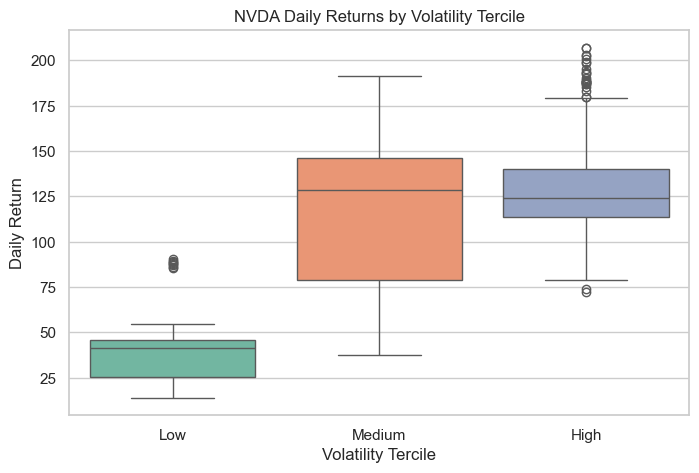

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot style
sns.set(style="whitegrid")

# Draw boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x="Vol_Tercile", y=asset, data=df, palette="Set2")
plt.title(f"{asset} Daily Returns by Volatility Tercile")
plt.xlabel("Volatility Tercile")
plt.ylabel("Daily Return")
plt.show()

## ANOVA

In [17]:
# fit ANOVA model
m = ols(f"{asset} ~ C(Vol_Tercile)", data=df).fit()

print(m.summary())

                            OLS Regression Results                            
Dep. Variable:                   NVDA   R-squared:                       0.618
Model:                            OLS   Adj. R-squared:                  0.617
Method:                 Least Squares   F-statistic:                     590.4
Date:                Sun, 16 Nov 2025   Prob (F-statistic):          3.44e-153
Time:                        10:23:05   Log-Likelihood:                -3587.4
No. Observations:                 732   AIC:                             7181.
Df Residuals:                     729   BIC:                             7195.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

In [18]:
# computing eta squared
eta2 = anova.loc["C(Vol_Tercile)", "sum_sq"] / anova["sum_sq"].sum()
print("η² =", eta2)

η² = 0.618303711528056
